In [28]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.metrics import mean_absolute_error
import optuna

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4897, 3)
(4897, 8)
(5150, 8)


UnboundLocalError: cannot access local variable 'X_train' where it is not associated with a value

In [ ]:
# XGBoost


#Tuning XGBoost through the Optuna library
def objective(trial):
  XGBoost = XGBRegressor(
      objective="reg:squarederror",
      n_estimators=1000,
      learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True), #sweeping 0.01 to 0.1 in the log scale for optimal learning rate
      max_depth=trial.suggest_int("max_depth",2,5), #checking max depth between 2 and 5
      subsample=trial.suggest_float("subsample",0.6,0.9), #sweeping subsample possibilites between 0.6 and 0.9
      colsample_bytree=trial.suggest_float("colsample_bytree",0.6,0.9), #sweeping bytree parameters between 0.6 and 0.9
      random_state=42
  )
  XGBoost.fit(
      X_train, y_train, eval_set=[(X_val, y_val)], verbose=False) #To see more model info set verbose=True
  predictions= XGBoost.predict(X_val)
  RMSE = root_mean_squared_error(y_val, predictions)
  return RMSE

#Finding the parameters that minimize the squared error 
optimization = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42)) # sampler ensures Optuna gives the same tuning results which gives reproducability between runs 
optimization.optimize(objective, n_trials=30) #Keeping at 30 to prevent overfitting with noise

#Showing what the parameters are
optimal_params = optimization.best_params
print("Optimal Parameters:", optimal_params)

#Running the XGBoost with the optimal parameters
XGBoost = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    **optimal_params,
    random_state=42,
)

XGBoost.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

#Calculating multiplicative error for XGBoost
XGBoost_Prediction = XGBoost.predict(X_test)
XGBoost_RMSE = root_mean_squared_error(y_test, XGBoost_Prediction)
XGBoost_Error = XGBoost_RMSE
print("XGBoost Error:", XGBoost_Error)

XGBoost_RMSE = mean_absolute_error(y_test, XGBoost_Prediction)
XGBoost_Error_MAE = XGBoost_RMSE
print("Mean XGBoost Error:", XGBoost_Error_MAE)

[I 2026-02-06 14:43:51,703] A new study created in memory with name: no-name-90a18300-ed59-45f3-b4a5-e9ae616a23a7
[I 2026-02-06 14:43:52,197] Trial 0 finished with value: 3096.1437082993607 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 5, 'subsample': 0.8195981825434215, 'colsample_bytree': 0.779597545259111}. Best is trial 0 with value: 3096.1437082993607.
[I 2026-02-06 14:43:52,454] Trial 1 finished with value: 11492.167453127813 and parameters: {'learning_rate': 0.014322493718230255, 'max_depth': 2, 'subsample': 0.6174250836504598, 'colsample_bytree': 0.8598528437324806}. Best is trial 0 with value: 3096.1437082993607.
[I 2026-02-06 14:43:52,830] Trial 2 finished with value: 3058.156877304393 and parameters: {'learning_rate': 0.039913058785616795, 'max_depth': 4, 'subsample': 0.6061753482887408, 'colsample_bytree': 0.8909729556485984}. Best is trial 2 with value: 3058.156877304393.
[I 2026-02-06 14:43:53,074] Trial 3 finished with value: 7685.538755132018 and 

Optimal Parameters: {'learning_rate': 0.08378108445295113, 'max_depth': 5, 'subsample': 0.7690895281676289, 'colsample_bytree': 0.6208982628946457}
XGBoost Error: 1926.9159578785773
Mean XGBoost Error: 226.24139404296858


598    41340.0
532    29250.0
289    46995.0
127    87240.0
295    38925.0
        ...   
32     46890.0
334    48585.0
584    64935.0
258    59010.0
385    38730.0
Name: time_to_next_ev_hr, Length: 800, dtype: float64
[41344.99  29197.018 47043.535 87234.28  38880.65  53374.652 31216.086
 47929.484 58559.094 36124.055 41909.89  38765.156 48155.53  54913.184
 37536.7   49116.953 34752.43  51615.465 82389.734 34993.074 29332.246
 47043.535 55756.938 39804.746 32182.791 86362.42  64050.03  46523.277
 37712.375 62493.027 35759.152 68725.87  53603.176 33072.926 35217.75
 54789.184 57627.49  30457.705 29511.451 68276.63  49066.47  38342.15
 85614.055 54789.184 57960.332 34316.58  30620.648 61267.043 55078.438
 49066.47  34182.605 39577.62  29839.812 53632.26  35547.77  34805.08
 32573.66  28034.246 57762.87  46175.29  55853.754 33892.555 58842.086
 49431.445 34576.68  28034.246 27063.012 31554.598 58447.723 50391.28
 46175.29  68276.63  60224.074 34562.113 39414.45  51615.465 34993.074
 353

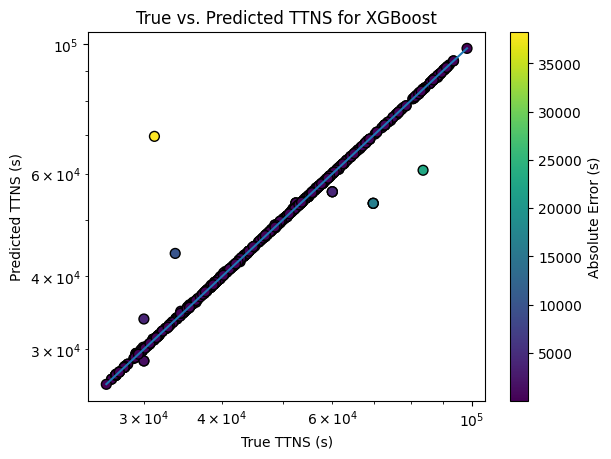

In [ ]:
#XGBoost Analysis

#Taking the target column and predictions out of the log scale to calculate the average error in seconds
#y_test_secs = y_test.reshape(1,-1)
y_test_secs = y_test
XG_pred_secs = XGBoost_Prediction
print(y_test_secs)
print(XG_pred_secs)
absolute_error_secs_XG = np.abs(XG_pred_secs - y_test_secs)

#printing the true vs predicted value and error in seconds for every recrod
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, XG_pred_secs, absolute_error_secs_XG)):
  print(f"Sample{i}: True = {true}s, Predicted = {pred}s, Error={abs_error}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, XG_pred_secs, c=absolute_error_secs_XG, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for XGBoost")
#plt.xscale('log')
#plt.yscale('log')
plt.show()

 96%|=================== | 766/800 [00:16<00:00]       

XG Boost Drivers: time_since     4580.122360
tide_deriv     4314.133187
tide_height    2879.204486
form_fac       2481.817122
slip_size      2347.159298
high_t_evt      411.500273
dtype: float64


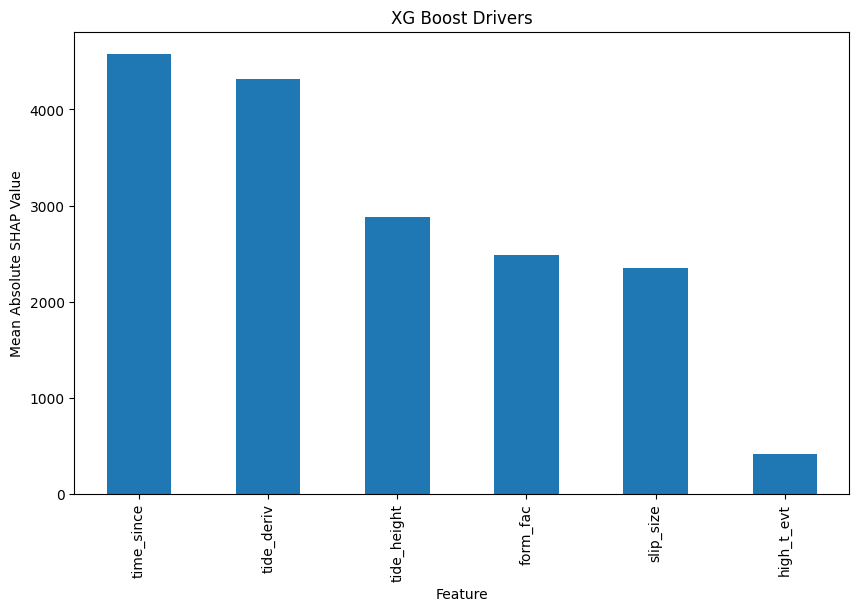

In [ ]:
# Driving parameters for XG 

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
X_shap = pd.DataFrame(X_shap, columns=feature_cols)
explainer_XG = shap.TreeExplainer(XGBoost, X_shap, feature_perturbation="interventional") #Using interventional to respect correlation between the features

shap_values_XG = explainer_XG.shap_values(X_shap) #Doing the tree analysis on XG using training data

XG_imp = pd.Series(np.abs(shap_values_XG).mean(axis=0), index=X_shap.columns).sort_values(ascending=False) #Analysis of driving parameters in XG

print("XG Boost Drivers:", XG_imp)

# Creating a bar graph showing the driving parameters for XGBoost 
plt.figure(figsize=(10, 6))
XG_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("XG Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()
